# Synthetic calibrated-Gaussian benchmark — VaR bias test (`Mains.multislice`)

This notebook probes whether the model is a **biased VaR estimator** by feeding it a synthetic
price series with a **fully known log-return distribution**:

* 5000 log-return steps drawn i.i.d. from a stationary Gaussian with mean 0 and
  sigma calibrated so that **exactly 98% of the probability mass lies in [-0.01, +0.01]**
  (`sigma = 0.01 / z_0.99 ≈ 0.0042986`). By symmetry the true 1%-quantile is **-0.01**, so
  a well-calibrated VaR at `var_level = 0.99` should sit at ≈ -0.01 and be violated on ~1% of test steps.
* Prices start at 1.0 and follow `P_t = P_{t-1} * exp(r_t)`, written to `datasets/SYNTH.csv`
  (ticker column `SYNTH`, same wide-CSV structure and calendar convention as `FOREX.csv`;
  the FOREX calendar is extended past 2020-12-18 to cover all 5001 price rows).

The run uses `Parameters_SYNTH.par` (same feature set / binning as the FOREX runs) and checks:

1. Is the modelled log-return pmf centered on 0 with ~98% mass in [-0.01, +0.01]?
2. Is VaR(99%) ≈ -0.01, and does it get violated at ~1%?
3. If not: which **effective `var_level`** puts the VaR estimate at -0.01 (an indirect
   calibration by remapping `var_level`), and which level yields an empirical 1% violation rate?

In [1]:
# Imports and static variables
import os
import importlib
from statistics import NormalDist

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import Utils
import FeatureGeneration as FG
import RBFBinner
import Mains
import Display

for m in (Utils, FG, Mains, Display):
    importlib.reload(m)
WORKDIR = os.path.dirname(os.path.abspath("Mains.py")) if os.path.exists("Mains.py") else os.getcwd()
os.chdir(WORKDIR)
FIGDIR = "figs/SYNTH"
os.makedirs(FIGDIR, exist_ok=True)
RUNDIR = "runs/SYNTH"  # isolate SYNTH artifacts from the FOREX runs in the CWD


def figpath(n, stem):
    """Numbered figure path under FIGDIR (``01_…`` through ``99_…``)."""
    return os.path.join(FIGDIR, f"{int(n):02d}_{stem}.png")


def save_fig(fig, n, stem):
    """Save *fig* to FIGDIR with a zero-padded sequence number."""
    path = figpath(n, stem)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path


PARAMFILE = "Parameters_SYNTH.par"
TICKER = "SYNTH"
VAR_LEVEL = 0.99          # left-tail VaR at quantile (1 - VAR_LEVEL) on the log-return pmf

# --- ground truth of the synthetic generator -------------------------------
N_STEPS = 5000            # number of i.i.d. Gaussian log-return steps
BAND = 0.01               # calibration band: P(|r| <= BAND) = BAND_MASS
BAND_MASS = 0.98
Z_99 = NormalDist().inv_cdf(0.5 + BAND_MASS / 2.0)   # = z_0.99 ≈ 2.3263
SIGMA = BAND / Z_99                                   # ≈ 0.0042986
TRUE_VAR_99 = -BAND       # true 1% quantile of the log-return distribution
SEED = 20260711

params = Utils.load_params(PARAMFILE)
TRNPAT = int(params["trnpat"])
VANPAT = int(params["vanpat"])
TENPAT = int(params["tenpat"])
OFFS = int(params["offs"])
WARMUP_PAT = int(params.get("warmup_pat", 0))
CFG = FG.feature_config(PARAMFILE)
PRIMARY_COL = CFG.primary_col        # 2 = daily log return (prediction target)
RETURN_NBIN = CFG.primary_nbin
BLOCK_STEP = TRNPAT + VANPAT + TENPAT
W = FG.feature_align(CFG)
DATA_CSV = params["timeseries_file"]

print(f"Working directory: {WORKDIR}")
print(f"sigma = {SIGMA:.7f}  (0.01 / z_0.99, z_0.99 = {Z_99:.6f})")
print(f"true P(|r| <= {BAND}) = {BAND_MASS}  |  true VaR({VAR_LEVEL:.0%}) = {TRUE_VAR_99}")
print(f"Per-block: trnpat={TRNPAT}  vanpat={VANPAT}  tenpat={TENPAT}  "
      f"block_step={BLOCK_STEP}  (offs={OFFS}, warmup_pat={WARMUP_PAT})")

Working directory: /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/financial
sigma = 0.0042986  (0.01 / z_0.99, z_0.99 = 2.326348)
true P(|r| <= 0.01) = 0.98  |  true VaR(99%) = -0.01
Per-block: trnpat=3900  vanpat=100  tenpat=990  block_step=4990  (offs=1, warmup_pat=0)


## 1. Generate `datasets/SYNTH.csv`

Fixed seed → reproducible. The CSV mirrors the `FOREX.csv` wide layout (`Date` + one price
column per ticker). The FOREX calendar (Sun–Fri, Saturdays skipped) only has 4371 rows, so it
is extended forward with the same weekday convention until all 5001 price rows are dated.

In [2]:
# Draw calibrated Gaussian log returns and integrate them into a price path.
rng = np.random.default_rng(SEED)
log_ret_true = rng.normal(0.0, SIGMA, N_STEPS)

prices = np.empty(N_STEPS + 1)
prices[0] = 1.0
prices[1:] = np.exp(np.cumsum(log_ret_true))   # P_t = P_{t-1} * exp(r_t)

# Calendar: FOREX dates, extended forward with the same skip-Saturday convention.
forex_dates = pd.read_csv(
    FG.dataset_path("FOREX.csv"), usecols=["Date"], parse_dates=["Date"])["Date"]
dates = list(forex_dates)
d = dates[-1]
while len(dates) < len(prices):
    d = d + pd.Timedelta(days=1)
    if d.dayofweek != 5:      # FOREX calendar has Sun-Fri rows (Saturdays missing)
        dates.append(d)
dates = pd.DatetimeIndex(dates[: len(prices)])

df_synth = pd.DataFrame({"Date": dates.strftime("%Y-%m-%d"), TICKER: prices})
csv_path = FG.dataset_path(DATA_CSV)
df_synth.to_csv(csv_path, index=False)

# Empirical sanity check of the drawn sample against the analytic calibration.
frac_in_band = float(np.mean(np.abs(log_ret_true) <= BAND))
emp_q01 = float(np.quantile(log_ret_true, 1.0 - VAR_LEVEL))
print(f"Wrote {csv_path}: {len(df_synth)} rows "
      f"({df_synth['Date'].iloc[0]} → {df_synth['Date'].iloc[-1]})")
print(f"Sample check ({N_STEPS} draws):")
print(f"  mean            = {log_ret_true.mean():+.6f}   (target 0)")
print(f"  std             = {log_ret_true.std():.6f}   (target {SIGMA:.6f})")
print(f"  P(|r| <= {BAND})  = {frac_in_band:.4f}     (target {BAND_MASS})")
print(f"  empirical 1%-q  = {emp_q01:+.6f}   (target {TRUE_VAR_99})")

df_raw = pd.read_csv(csv_path, parse_dates=["Date"])   # same handle name as nb-FOREX

Wrote /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/financial/datasets/SYNTH.csv: 5001 rows (2007-01-01 → 2022-12-23)
Sample check (5000 draws):
  mean            = -0.000100   (target 0)
  std             = 0.004241   (target 0.004299)
  P(|r| <= 0.01)  = 0.9836     (target 0.98)
  empirical 1%-q  = -0.009663   (target -0.01)


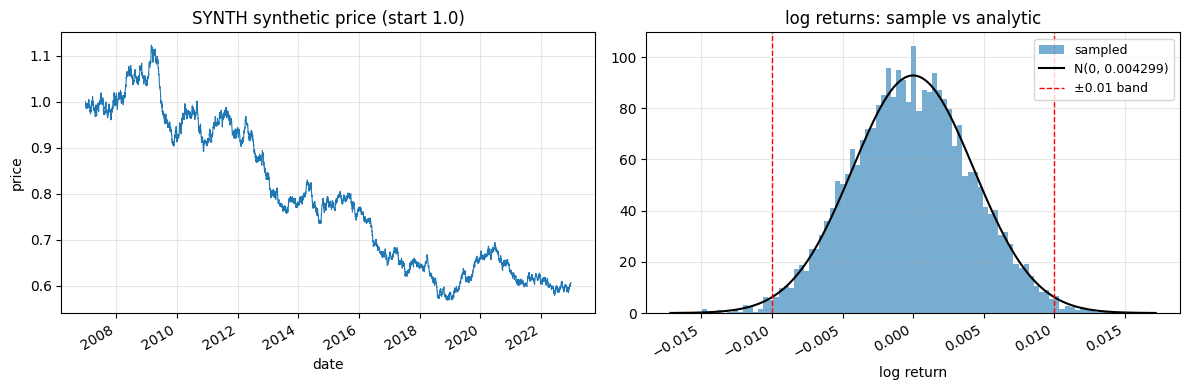

In [3]:
# Visual check: price path and log-return histogram vs the analytic density.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df_raw["Date"], prices, lw=0.8)
axes[0].set_title(f"{TICKER} synthetic price (start 1.0)")
axes[0].set_xlabel("date")
axes[0].set_ylabel("price")
axes[0].grid(alpha=0.3)

axes[1].hist(log_ret_true, bins=80, density=True, alpha=0.6, label="sampled")
xs = np.linspace(-4 * SIGMA, 4 * SIGMA, 400)
axes[1].plot(xs, np.exp(-0.5 * (xs / SIGMA) ** 2) / (SIGMA * np.sqrt(2 * np.pi)),
             "k-", lw=1.5, label=f"N(0, {SIGMA:.4g})")
for edge in (-BAND, BAND):
    axes[1].axvline(edge, color="red", ls="--", lw=1,
                    label="±0.01 band" if edge < 0 else None)
axes[1].set_title("log returns: sample vs analytic")
axes[1].set_xlabel("log return")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
save_fig(fig, 1, "synthetic_series")
plt.show()

## 2. Run multislice (model) and analyze (metrics)

Single ticker, single block (`trnpat=3900, vanpat=100, tenpat=990` → 989 scored test steps,
so ~10 violations are expected at a calibrated 1% VaR). Artifacts go to `runs/SYNTH/` so the
FOREX outputs in the working directory are untouched.

In [4]:
# Encode features, write schedule.dat, and invoke ltslmain.
# Set exefile=None to skip the simulator when artifacts are already on disk.
run = Mains.run_multislice(
    PARAMFILE,
    exefile="./ltslmain",
    rundir=RUNDIR,
    verbose=True,
)

Mains.run_multislice: timeseries_file=SYNTH.csv
  tickers=['SYNTH']
  trnpat=3900  vanpat=100  tenpat=990  warmup_pat=0  block_step=4990
  calendar_start=2  max_calendar_end=5001  n_blocks=1
  rundir=runs/SYNTH
  total feature rows=4990  (per-phase totals: trn=3900, van=100, ten=990)


Hj = 1 nactHi = 3 nsilHi = 0 denHi = 3 Mi = 2500 denNi = 7500


paramfile = params.par
schedule_file = schedule.dat  (1 blocks; sum trn=3900 van=100 ten=990)
taup = 3.900
eps = 2.6e-04
K_mode = logarithmic
bdebias = 1
BLOCK 1/1  trnpat=3900 vanpat=100 tenpat=990  (simstep=0)
Total simsteps = 8886, time elapsed = 22.045 sec


In [5]:
# Metrics from saved netw1_outpop_*_dist.bin — safe to rerun without ltslmain.
result = Mains.analyze_multislice(
    run["paramfile"],
    plan=run["plan"],
    rundir=run.get("rundir"),
    metrics=("rmse", "persistence", "hit", "var",
             "quadratic_loss", "smooth_loss", "tick_loss", "firm_loss"),
    var_level=VAR_LEVEL,
    verbose=True,
)

ti = result["tickers"].index(TICKER)
print(f"\nDeepVaR backtest ({TICKER}, test phase, alpha={result['var_level']}):")
print(f"  tick_loss        = {result['tick_loss'][ti]:.6g}")
print(f"  violations       = {int(result['n_violations'][ti])}  "
      f"rate = {result['violation_rate'][ti]:.3%}   "
      f"(expected {(1 - VAR_LEVEL):.1%} → ~{(1 - VAR_LEVEL) * (TENPAT - OFFS):.1f} "
      f"of {TENPAT - OFFS} test steps)")

Mains.analyze_multislice: paramfile=runs/SYNTH/params.par  rundir=runs/SYNTH
  train: mean RMSE = 0.0042749  persistence = 0.0060365  (1/1 valid entries)
  val  : mean RMSE = 0.004391  persistence = 0.0061074  (1/1 valid entries)
  test : mean RMSE = 0.004101  persistence = 0.0058455  (1/1 valid entries)

DeepVaR backtest (SYNTH, test phase, alpha=0.99):
  tick_loss        = 0.00951593
  violations       = 10  rate = 1.011%   (expected 1.0% → ~9.9 of 989 test steps)


## 3. Is the modelled log-return distribution calibrated?

Because the generator is i.i.d., **every** test step has the same true conditional
distribution `N(0, sigma)`. So the per-step predicted pmfs should all look alike:
centered on 0, with ~98% of their mass inside [-0.01, +0.01] and 1% below -0.01.

We evaluate, per test-phase pmf:

* the pmf mean (target 0),
* the CDF mass inside [-0.01, +0.01] (target 0.98),
* the left-tail mass below -0.01 (target 0.01) — this is the direct check of the
  "extreme outer bins get too much probability" hypothesis,
* the 1%-quantile a.k.a. VaR(99%) (target -0.01).

SYNTH: 989 scored test steps

statistic                                  mean       median     target
pmf mean E[r]                         -0.000117    -0.000117    +0.0000
mass in [-0.01, +0.01]                +0.981053    +0.982272    +0.9800
left-tail mass below -0.01            +0.018947    +0.017728    +0.0100
VaR(99%) = 1%-quantile                -0.009672    -0.009672    -0.0100


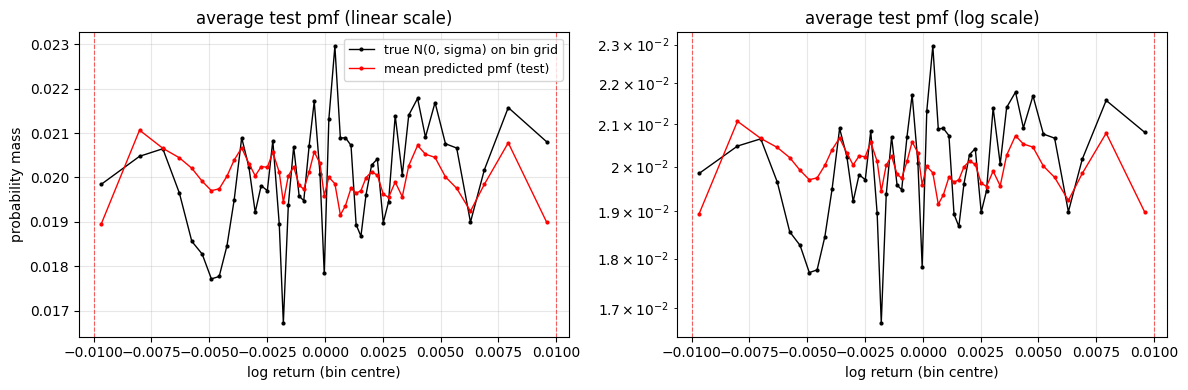

In [6]:
# Stitch the per-step output pmfs and restrict to the test phase.
series = Display.stitch_multislice_ticker(
    run["paramfile"], TICKER, plan=run["plan"], rundir=run.get("rundir"))
centers = np.asarray(series["centers"], dtype=float)

test_idx = np.where(series["phase"] == 2)[0]
pnl = series["feats"][series["x_feat"][test_idx], PRIMARY_COL].astype(float)  # realized log returns
dists = np.asarray(series["dists"][test_idx], dtype=float)
s = dists.sum(axis=1, keepdims=True)
dists = dists / np.where(s > 0, s, 1.0)
cdfs = np.cumsum(dists, axis=1)      # same discrete-CDF convention as Utils.discrete_pmf_quantile

n_test = len(test_idx)
print(f"{TICKER}: {n_test} scored test steps")

# Per-step statistics of the predicted pmf.
pmf_mean = dists @ centers                                            # E[r]  (target 0)
F = lambda x: np.array([np.interp(x, centers, c) for c in cdfs])      # F(x) per step
mass_below = F(-BAND)                                                 # target 0.01
mass_in_band = F(BAND) - F(-BAND)                                     # target 0.98
var99 = np.array([Utils.discrete_pmf_quantile(p, centers, 1.0 - VAR_LEVEL)
                  for p in dists])                                    # target -0.01

rows = [
    ("pmf mean E[r]",              pmf_mean,    0.0),
    (f"mass in [-{BAND}, +{BAND}]", mass_in_band, BAND_MASS),
    (f"left-tail mass below -{BAND}", mass_below, 1.0 - VAR_LEVEL),
    (f"VaR({VAR_LEVEL:.0%}) = 1%-quantile", var99, TRUE_VAR_99),
]
print(f"\n{'statistic':34s} {'mean':>12s} {'median':>12s} {'target':>10s}")
for name, arr, target in rows:
    print(f"{name:34s} {np.mean(arr):>+12.6f} {np.median(arr):>+12.6f} {target:>+10.4f}")

# Average predicted test pmf vs the analytic Gaussian, both discretized on the bin grid.
avg_pmf = dists.mean(axis=0)
nd = NormalDist(0.0, SIGMA)
edges = np.empty(len(centers) + 1)
edges[1:-1] = 0.5 * (centers[:-1] + centers[1:])
edges[0], edges[-1] = -np.inf, np.inf
true_pmf = np.array([nd.cdf(edges[i + 1]) - nd.cdf(edges[i])
                     for i in range(len(centers))])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, yscale in zip(axes, ("linear", "log")):
    ax.plot(centers, true_pmf, "k.-", lw=1, ms=4, label="true N(0, sigma) on bin grid")
    ax.plot(centers, avg_pmf, "r.-", lw=1, ms=4, label="mean predicted pmf (test)")
    for edge in (-BAND, BAND):
        ax.axvline(edge, color="red", ls="--", lw=0.8, alpha=0.6)
    ax.set_yscale(yscale)
    ax.set_xlabel("log return (bin centre)")
    ax.set_title(f"average test pmf ({yscale} scale)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("probability mass")
axes[0].legend(fontsize=9)
plt.tight_layout()
save_fig(fig, 2, "avg_pmf_vs_truth")
plt.show()

## 4. Remapping `var_level` — indirect calibration

Two complementary calibration curves over a grid of `var_level` values:

* **mean predicted VaR vs level** — solve for the level whose average VaR estimate lands on
  the true -0.01 quantile. If the model were unbiased this would be 0.99.
* **empirical violation rate vs level** — solve for the level whose violation rate is 1%.
  This is the *backtest-consistent* remapping: querying the model at that level and calling
  it "VaR(99%)" would produce a correctly-sized 1% exceedance frequency.

Deepest representable VaR (leftmost bin centre) = -0.00967  (true 1%-quantile -0.010)
Nominal var_level = 0.99
  mean predicted VaR at 99%: -0.00967 (true quantile -0.01000)
Remapped levels:
  var_level* with mean VaR = -0.01     : unreachable — mean VaR saturates at -0.00967 (grid floor -0.00967); closest at level 0.9880
  var_level* with violation rate = 1% : outside grid — closest is level 0.9860 with rate 1.011% (10 of 989)


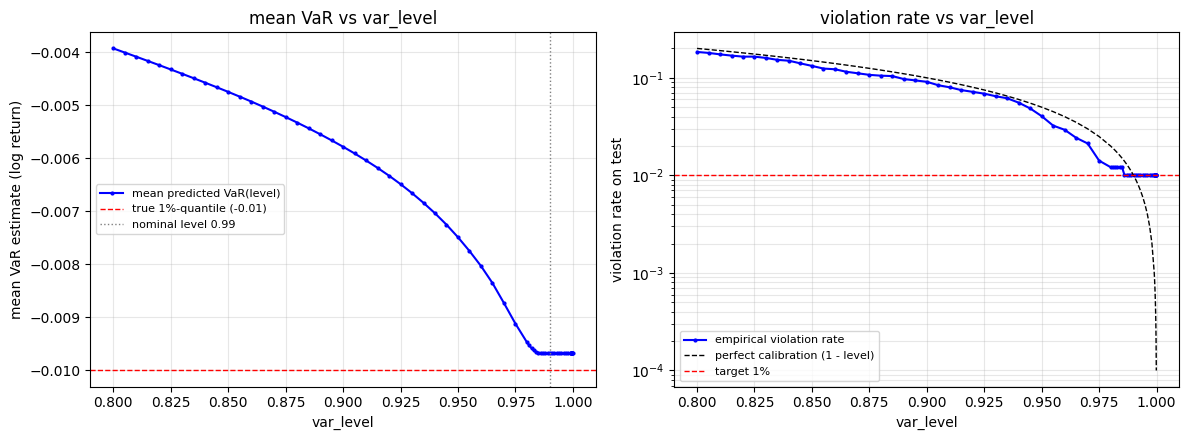

In [7]:
# Sweep var_level and evaluate the resulting VaR estimates against truth and backtest.
levels = np.concatenate([
    np.linspace(0.80, 0.98, 37),
    np.linspace(0.981, 0.999, 19),
    np.linspace(0.9991, 0.9999, 9),   # deep-tail refinement for the remapping
])
mean_var = np.empty_like(levels)
viol_rate = np.empty_like(levels)
for i, L in enumerate(levels):
    q = 1.0 - L
    var_L = np.array([np.interp(q, cdf, centers) for cdf in cdfs])
    mean_var[i] = var_L.mean()
    viol_rate[i] = float(np.mean(pnl < var_L))


def _crossing(levels, curve, target):
    """Level at which the monotone-decreasing *curve* crosses *target* (nan if outside grid)."""
    lo, hi = curve.min(), curve.max()
    if not (lo <= target <= hi):
        return float("nan")
    order = np.argsort(curve)
    return float(np.interp(target, curve[order], levels[order]))


level_var_match = _crossing(levels, mean_var, TRUE_VAR_99)      # mean VaR = -0.01
level_viol_match = _crossing(levels, viol_rate, 1.0 - VAR_LEVEL)  # violation rate = 1%

# Structural limit: the inverse-CDF interp can never go below the leftmost bin
# centre, so the deepest representable VaR is centers[0]. With rbf-quantile and
# n bins that centre sits at the (0.5/n) empirical quantile of the pooled
# encoding sample — for n=50 that is exactly the 1% quantile, i.e. VaR(99%) is
# at the very edge of what the discrete grid can express.
var_floor = float(centers[0])
print(f"Deepest representable VaR (leftmost bin centre) = {var_floor:+.5f}  "
      f"(true 1%-quantile {TRUE_VAR_99:+.3f})")
print(f"Nominal var_level = {VAR_LEVEL}")
print(f"  mean predicted VaR at {VAR_LEVEL:.0%}: "
      f"{mean_var[np.argmin(np.abs(levels - VAR_LEVEL))]:+.5f} "
      f"(true quantile {TRUE_VAR_99:+.5f})")
print("Remapped levels:")
if np.isfinite(level_var_match):
    print(f"  var_level* with mean VaR = {TRUE_VAR_99}     : {level_var_match:.4f}")
else:
    i_best = int(np.argmin(np.abs(mean_var - TRUE_VAR_99)))
    print(f"  var_level* with mean VaR = {TRUE_VAR_99}     : unreachable — mean VaR "
          f"saturates at {mean_var.min():+.5f} (grid floor {var_floor:+.5f}); "
          f"closest at level {levels[i_best]:.4f}")
if np.isfinite(level_viol_match):
    print(f"  var_level* with violation rate = {1 - VAR_LEVEL:.0%} : {level_viol_match:.4f}")
else:
    i_best = int(np.argmin(np.abs(viol_rate - (1.0 - VAR_LEVEL))))
    print(f"  var_level* with violation rate = {1 - VAR_LEVEL:.0%} : outside grid — closest is "
          f"level {levels[i_best]:.4f} with rate {viol_rate[i_best]:.3%} "
          f"({int(round(viol_rate[i_best] * n_test))} of {n_test})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(levels, mean_var, "b.-", ms=4, label="mean predicted VaR(level)")
ax.axhline(TRUE_VAR_99, color="red", ls="--", lw=1, label=f"true 1%-quantile ({TRUE_VAR_99})")
ax.axvline(VAR_LEVEL, color="gray", ls=":", lw=1, label=f"nominal level {VAR_LEVEL}")
if np.isfinite(level_var_match):
    ax.axvline(level_var_match, color="green", ls="--", lw=1,
               label=f"remap: level = {level_var_match:.4f}")
ax.set_xlabel("var_level")
ax.set_ylabel("mean VaR estimate (log return)")
ax.set_title("mean VaR vs var_level")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(levels, viol_rate, "b.-", ms=4, label="empirical violation rate")
ax.plot(levels, 1.0 - levels, "k--", lw=1, label="perfect calibration (1 - level)")
ax.axhline(1.0 - VAR_LEVEL, color="red", ls="--", lw=1, label="target 1%")
if np.isfinite(level_viol_match):
    ax.axvline(level_viol_match, color="green", ls="--", lw=1,
               label=f"remap: level = {level_viol_match:.4f}")
ax.set_xlabel("var_level")
ax.set_ylabel("violation rate on test")
ax.set_yscale("log")
ax.set_title("violation rate vs var_level")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
save_fig(fig, 3, "var_level_calibration")
plt.show()

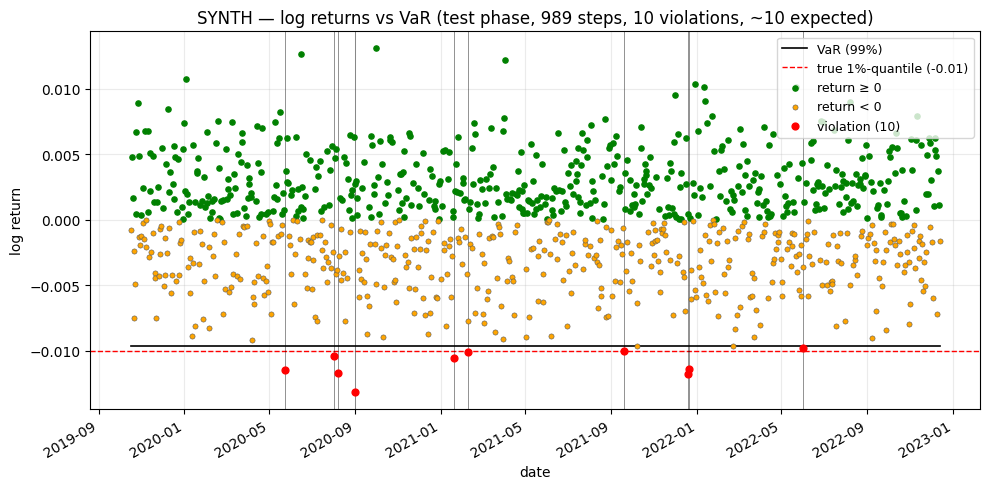

In [8]:
# VaR violation timeline — test phase at the nominal var_level.
sym_dates = Display.ticker_feat_dates(df_raw["Date"], series)
x = sym_dates.iloc[series["x_feat"][test_idx]].values
var = np.asarray(result["var"][TICKER], dtype=float)[test_idx]

violation = pnl < var
pos_ok = (~violation) & (pnl >= 0)
neg_ok = (~violation) & (pnl < 0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, var, color="black", lw=1.2, label=f"VaR ({VAR_LEVEL:.0%})")
ax.axhline(TRUE_VAR_99, color="red", ls="--", lw=1,
           label=f"true 1%-quantile ({TRUE_VAR_99})")
ax.scatter(x[pos_ok], y=pnl[pos_ok], c="green", s=14, zorder=3, label="return ≥ 0")
ax.scatter(x[neg_ok], y=pnl[neg_ok], c="orange", s=14, zorder=3,
           edgecolors="0.35", linewidths=0.4, label="return < 0")
ax.scatter(x[violation], y=pnl[violation], c="red", s=24, zorder=4,
           label=f"violation ({violation.sum()})")
for xi in x[violation]:
    ax.axvline(xi, color="black", lw=0.6, alpha=0.5)

ax.set_xlabel("date")
ax.set_ylabel("log return")
ax.set_title(
    f"{TICKER} — log returns vs VaR (test phase, {len(test_idx)} steps, "
    f"{int(violation.sum())} violations, "
    f"~{(1 - VAR_LEVEL) * len(test_idx):.0f} expected)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
save_fig(fig, 4, "var_violations_test")
plt.show()

In [9]:
# Summary verdict.
mean_var99 = float(var99.mean())
n_viol = int(np.sum(pnl < var99))
p_exp = 1.0 - VAR_LEVEL
exp_viol = p_exp * n_test
# Binomial z-score of the violation count under perfect calibration.
z_viol = (n_viol - exp_viol) / np.sqrt(n_test * p_exp * (1.0 - p_exp))

print("=" * 72)
print(f"SYNTH benchmark verdict (true distribution N(0, {SIGMA:.5f}), i.i.d.)")
print("=" * 72)
print(f"pmf centering        : mean E[r] = {pmf_mean.mean():+.6f}          (target 0)")
print(f"band mass            : P(|r|<=0.01) = {mass_in_band.mean():.4f}       (target {BAND_MASS})")
print(f"left-tail mass       : P(r<-0.01)  = {mass_below.mean():.4f}       (target {p_exp:.2f})")
print(f"VaR({VAR_LEVEL:.0%})             : mean = {mean_var99:+.5f}           (target {TRUE_VAR_99:+.3f})")
print(f"violations           : {n_viol} of {n_test} = {n_viol / n_test:.3%}   "
      f"(expected ~{exp_viol:.1f} = {p_exp:.1%}, z = {z_viol:+.2f})")
if np.isfinite(level_var_match):
    print(f"remap (mean VaR)     : var_level* = {level_var_match:.4f} puts mean VaR at {TRUE_VAR_99}")
if np.isfinite(level_viol_match):
    print(f"remap (backtest)     : var_level* = {level_viol_match:.4f} yields a {p_exp:.0%} violation rate")
print()
if z_viol > 2.0:
    print("→ ANTI-conservative on this calibrated stationary input: the model violates its")
    print("  VaR significantly more often than the nominal rate. Two compounding effects:")
    print(f"  (1) the predicted pmf carries ~{mass_below.mean():.1%} mass below -0.01 (target {p_exp:.0%}),")
    print("      i.e. the outer bins are somewhat over-weighted, yet")
    print("  (2) the inverse-CDF readout cannot go deeper than the leftmost bin centre")
    print(f"      ({float(centers[0]):+.5f}), so the VaR estimate saturates just above the true")
    print("      -0.01 quantile. If var_level remapping saturates (see above), calibration")
    print("      needs a deeper/finer bin grid (larger return_nbin, or centres extending")
    print("      past the 1% empirical quantile) rather than a level remap alone.")
elif z_viol < -2.0:
    print("→ CONSERVATIVE on this calibrated stationary input: too few violations, VaR too")
    print("  extreme — consistent with the outer bins carrying more mass than the data supports.")
else:
    print("→ Violation count is statistically compatible with perfect calibration; the")
    print("  conservatism on FOREX likely comes from non-stationarity / pooled binning")
    print("  rather than an intrinsic bias of the estimator.")

SYNTH benchmark verdict (true distribution N(0, 0.00430), i.i.d.)
pmf centering        : mean E[r] = -0.000117          (target 0)
band mass            : P(|r|<=0.01) = 0.9811       (target 0.98)
left-tail mass       : P(r<-0.01)  = 0.0189       (target 0.01)
VaR(99%)             : mean = -0.00967           (target -0.010)
violations           : 10 of 989 = 1.011%   (expected ~9.9 = 1.0%, z = +0.04)

→ Violation count is statistically compatible with perfect calibration; the
  conservatism on FOREX likely comes from non-stationarity / pooled binning
  rather than an intrinsic bias of the estimator.


## 5. Does linear binning (`binmode rbf`) fix the tail?

Hypothesis: the quantile layout is the wrong tool for tail quantiles at this bin count.
With `rbf-quantile` and `return_nbin = n`, centres sit at the `(i+0.5)/n` empirical quantiles,
so the **leftmost centre is exactly the (0.5/n) quantile** — for n=50 that is the 1% quantile,
i.e. VaR(99%) lands on the very edge of the representable grid (the saturation seen above), and
only ~0.5 bins resolve everything beyond it.

`binmode rbf` instead spaces centres **linearly over the 0.5%/99.5% winsor range**. For our
Gaussian that range is ≈ ±0.0111, so the leftmost centre sits *deeper* than the true -0.01
quantile, and the uniform spacing puts relatively more centres in the sparse tail region than
quantile binning does — potentially better VaR resolution **without increasing `return_nbin`**.

The trade-off to watch: linear binning has *coarser* resolution in the bulk (where quantile
binning concentrated its centres), which may cost RMSE/bulk calibration.

> **Encoder bug found & fixed here:** `RBFBinner.Encoder1D.from_linear_winsor` used a default
> kernel width `sigma = 1/n_centers` in **absolute data units** — sensible for legacy
> normalized-price channels (range ≈ 1) but ≈ 0.9× the *entire* winsor range for log returns
> (width ≈ 0.021). Every `rbf` encoding collapsed to a near-uniform pattern
> (normalized entropy > 0.997), the network learned a flat pmf, and the first version of this
> comparison was meaningless. The default is now scale-invariant
> (`sigma = (hi - lo) / n_centers`, one centre spacing); results below use the fixed encoder.

> **Second bug found & fixed here (`ltslmain.cpp`): `eps` was never forwarded to the
> projection.** The .par `eps` was parsed and its default `1/(1+trnpat)` printed at startup,
> but `Prj` silently kept the library default `EPS = 1e-7`. Consequence: the P-trace floors
> did not regularize the log-odds weights of rarely sampled bins. On the linear grid the
> outer *joint* bins (return × variance outer product, 2500 units) see only a handful of
> coincidences in 3900 steps, so their weights `log(Pji/(Pi·Pj))` were multi-nat sampling
> noise which the softmax readout converted into randomly placed pmf peaks — 54% of test
> steps peaked in the outermost 10 of 50 bins, and the *average* pmf came out flat even
> though the encodings and the average target were perfectly bell-shaped. With
> `ltslprj_md1->seteps(eps)` wired in (default eps = 2.6e-4), the outer-peak fraction drops
> to ~9% and individual pmfs are centred again.
>
> A *systematic* tail excess remained at any eps and was a design property of the trace floor:
> `Zj = act·(1-eps) + eps` over 2500 joint units injects `2500·eps` of uniform mass into the
> learned prior `Bj = log(Pj)` — ≈ 40% uniform admixture at the default eps — which compressed
> the recalled bell (edge bins came out ~4–5× too heavy, bulk bins ~0.6×).
>
> **Third fix (`bdebias`, default on):** at weight-update time the floor is inverted analytically
> when computing `Bj` only: `p̂ = max((Pj−eps)/(1−eps), eps²)`, `Bj = log(p̂)`. The weights
> `Wji = log(Pji/(Pi·Pj))` are left untouched, so the floor still regularizes their sampling
> noise. With `bdebias=1` (wired via `ltslprj_md1->setbdebias` and the `.par` key `bdebias`),
> the `rbf-quantile` average pmf tracks the true bell across all bin groups (ratio ≈ 1) and the
> backtest passes at the nominal 1% level. The linear `rbf` grid still shows residual tail
> overweight from its winsor geometry, not from the uniform floor.

In [10]:
# Clone the paramfile with binmode rbf and run the identical schedule into runs/SYNTH_rbf.
PARAMFILE_RBF = "Parameters_SYNTH_rbf.par"
params_rbf = Utils.load_params(PARAMFILE)
params_rbf["binmode"] = "rbf"
Utils.write_params(PARAMFILE_RBF, params_rbf, preserve_comments=False)
print(f"Wrote {PARAMFILE_RBF} (binmode=rbf, all other parameters identical)")

run_rbf = Mains.run_multislice(
    PARAMFILE_RBF,
    exefile="./ltslmain",
    rundir="runs/SYNTH_rbf",
    verbose=True,
)

result_rbf = Mains.analyze_multislice(
    run_rbf["paramfile"],
    plan=run_rbf["plan"],
    rundir=run_rbf.get("rundir"),
    metrics=("rmse", "persistence", "var",
             "quadratic_loss", "smooth_loss", "tick_loss", "firm_loss"),
    var_level=VAR_LEVEL,
    verbose=True,
)

Wrote Parameters_SYNTH_rbf.par (binmode=rbf, all other parameters identical)
Mains.run_multislice: timeseries_file=SYNTH.csv
  tickers=['SYNTH']
  trnpat=3900  vanpat=100  tenpat=990  warmup_pat=0  block_step=4990
  calendar_start=2  max_calendar_end=5001  n_blocks=1
  rundir=runs/SYNTH_rbf
  total feature rows=4990  (per-phase totals: trn=3900, van=100, ten=990)


Hj = 1 nactHi = 3 nsilHi = 0 denHi = 3 Mi = 2500 denNi = 7500


paramfile = params.par
schedule_file = schedule.dat  (1 blocks; sum trn=3900 van=100 ten=990)
taup = 3.900
eps = 2.6e-04
K_mode = logarithmic
bdebias = 1
BLOCK 1/1  trnpat=3900 vanpat=100 tenpat=990  (simstep=0)
Total simsteps = 8886, time elapsed = 22.068 sec


Mains.analyze_multislice: paramfile=runs/SYNTH_rbf/params.par  rundir=runs/SYNTH_rbf
  train: mean RMSE = 0.0042769  persistence = 0.0060365  (1/1 valid entries)
  val  : mean RMSE = 0.0043499  persistence = 0.0061074  (1/1 valid entries)
  test : mean RMSE = 0.0040961  persistence = 0.0058455  (1/1 valid entries)


In [11]:
# Identical tail-calibration evaluation for both binmodes.
def evaluate_tail(run):
    """Test-phase tail statistics + var_level sweep for one multislice run."""
    series = Display.stitch_multislice_ticker(
        run["paramfile"], TICKER, plan=run["plan"], rundir=run.get("rundir"))
    centers = np.asarray(series["centers"], dtype=float)
    t_idx = np.where(series["phase"] == 2)[0]
    pnl = series["feats"][series["x_feat"][t_idx], PRIMARY_COL].astype(float)
    p = np.asarray(series["dists"][t_idx], dtype=float)
    s = p.sum(axis=1, keepdims=True)
    p = p / np.where(s > 0, s, 1.0)
    cdf = np.cumsum(p, axis=1)

    Fx = lambda x: np.array([np.interp(x, centers, c) for c in cdf])
    var99 = np.array([Utils.discrete_pmf_quantile(pi, centers, 1.0 - VAR_LEVEL)
                      for pi in p])
    mv, vr = np.empty_like(levels), np.empty_like(levels)
    for i, L in enumerate(levels):
        var_L = np.array([np.interp(1.0 - L, c, centers) for c in cdf])
        mv[i] = var_L.mean()
        vr[i] = float(np.mean(pnl < var_L))

    return {
        "centers"      : centers,
        "pnl"          : pnl,
        "dists"        : p,
        "avg_pmf"      : p.mean(axis=0),
        "pmf_mean"     : p @ centers,
        "mass_in_band" : Fx(BAND) - Fx(-BAND),
        "mass_below"   : Fx(-BAND),
        "var99"        : var99,
        "n_viol"       : int(np.sum(pnl < var99)),
        "n_test"       : len(t_idx),
        "mean_var"     : mv,
        "viol_rate"    : vr,
        "floor"        : float(centers[0]),
        "level_var_match"  : _crossing(levels, mv, TRUE_VAR_99),
        "level_viol_match" : _crossing(levels, vr, 1.0 - VAR_LEVEL),
    }


ev = {"rbf-quantile": evaluate_tail(run), "rbf": evaluate_tail(run_rbf)}

p_exp = 1.0 - VAR_LEVEL
print(f"{'statistic':38s} {'rbf-quantile':>14s} {'rbf (linear)':>14s} {'target':>10s}")
print("-" * 80)
fmt_rows = [
    ("leftmost bin centre (VaR floor)", lambda e: e["floor"], TRUE_VAR_99),
    ("pmf mean E[r]", lambda e: float(e["pmf_mean"].mean()), 0.0),
    (f"mass in [-{BAND}, +{BAND}]", lambda e: float(e["mass_in_band"].mean()), BAND_MASS),
    (f"left-tail mass below -{BAND}", lambda e: float(e["mass_below"].mean()), p_exp),
    (f"mean VaR({VAR_LEVEL:.0%})", lambda e: float(e["var99"].mean()), TRUE_VAR_99),
]
for name, fn, target in fmt_rows:
    print(f"{name:38s} {fn(ev['rbf-quantile']):>+14.5f} {fn(ev['rbf']):>+14.5f} {target:>+10.4f}")
for name, fn in [
    ("violations (of %d)" % ev["rbf"]["n_test"], lambda e: f"{e['n_viol']}"),
    ("violation rate", lambda e: f"{e['n_viol'] / e['n_test']:.3%}"),
    ("remap level (mean VaR = -0.01)",
     lambda e: f"{e['level_var_match']:.4f}" if np.isfinite(e['level_var_match']) else "saturates"),
    ("remap level (viol rate = 1%)",
     lambda e: f"{e['level_viol_match']:.4f}" if np.isfinite(e['level_viol_match']) else "outside grid"),
]:
    print(f"{name:38s} {fn(ev['rbf-quantile']):>14s} {fn(ev['rbf']):>14s}")
print(f"\n(expected violations at a calibrated {VAR_LEVEL:.0%} VaR: "
      f"~{p_exp * ev['rbf']['n_test']:.1f} = {p_exp:.1%})")

# Bulk accuracy check: does linear binning cost RMSE?
for label, res in (("rbf-quantile", result), ("rbf", result_rbf)):
    r = np.asarray(res["rmse"], dtype=float)
    print(f"RMSE ({label:12s}): train={np.nanmean(r[:, 0, :]):.5f}  "
          f"val={np.nanmean(r[:, 1, :]):.5f}  test={np.nanmean(r[:, 2, :]):.5f}")

statistic                                rbf-quantile   rbf (linear)     target
--------------------------------------------------------------------------------
leftmost bin centre (VaR floor)              -0.00967       -0.01061    -0.0100
pmf mean E[r]                                -0.00012       -0.00004    +0.0000
mass in [-0.01, +0.01]                       +0.98105       +0.93863    +0.9800
left-tail mass below -0.01                   +0.01895       +0.03958    +0.0100
mean VaR(99%)                                -0.00967       -0.01061    -0.0100
violations (of 989)                                10              5
violation rate                                 1.011%         0.506%
remap level (mean VaR = -0.01)              saturates         0.9607
remap level (viol rate = 1%)             outside grid         0.9478

(expected violations at a calibrated 99% VaR: ~9.9 = 1.0%)
RMSE (rbf-quantile): train=0.00427  val=0.00439  test=0.00410
RMSE (rbf         ): train=0.00428  val=0

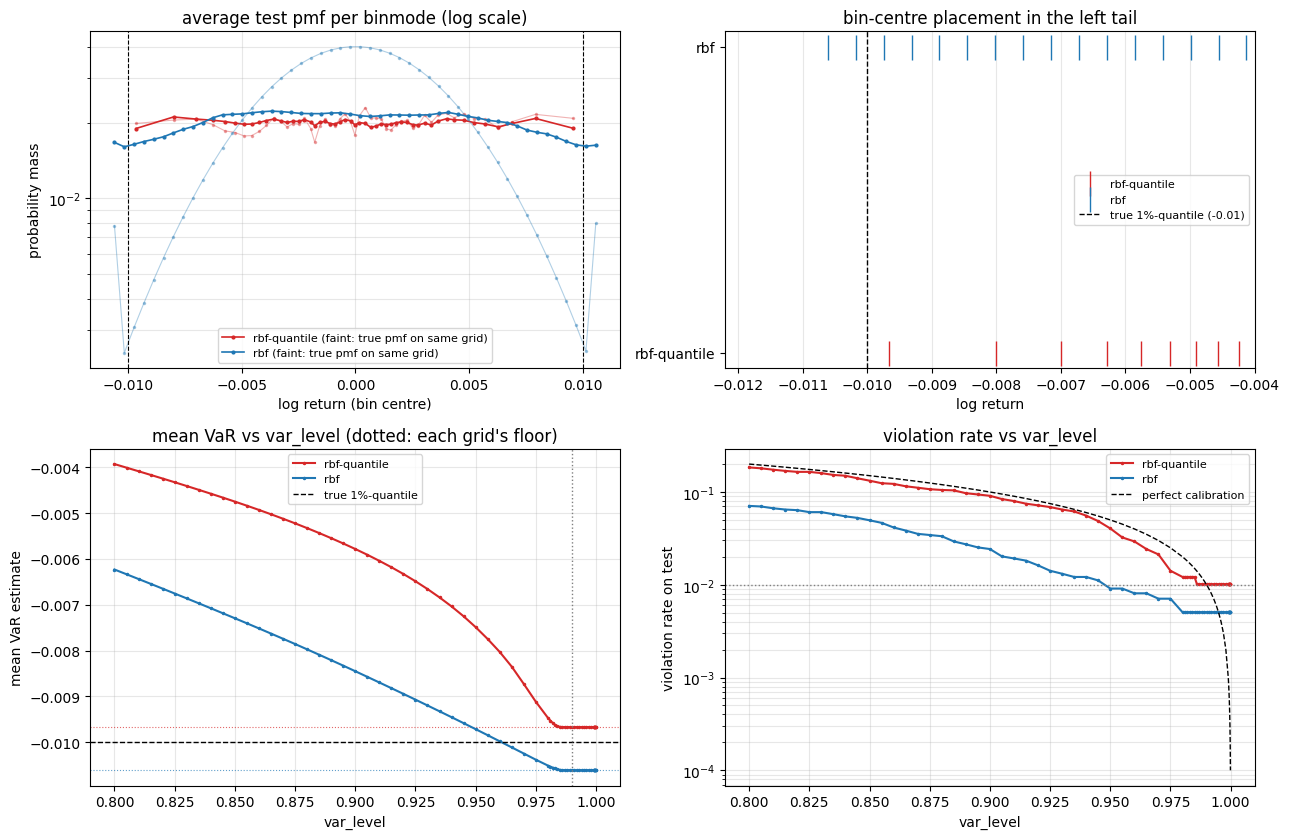

In [12]:
# Side-by-side: average test pmf (with centre placement) and calibration curves.
colors = {"rbf-quantile": "tab:red", "rbf": "tab:blue"}
nd = NormalDist(0.0, SIGMA)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))

# (a) average pmf on the bin grid, log scale — shows tail mass and centre reach.
ax = axes[0, 0]
for label, e in ev.items():
    c = e["centers"]
    edges = np.empty(len(c) + 1)
    edges[1:-1] = 0.5 * (c[:-1] + c[1:])
    edges[0], edges[-1] = -np.inf, np.inf
    tp = np.array([nd.cdf(edges[i + 1]) - nd.cdf(edges[i]) for i in range(len(c))])
    ax.plot(c, tp, ".-", lw=0.8, ms=3, color=colors[label], alpha=0.35)
    ax.plot(c, e["avg_pmf"], ".-", lw=1.2, ms=4, color=colors[label],
            label=f"{label} (faint: true pmf on same grid)")
ax.axvline(-BAND, color="k", ls="--", lw=0.8)
ax.axvline(BAND, color="k", ls="--", lw=0.8)
ax.set_yscale("log")
ax.set_xlabel("log return (bin centre)")
ax.set_ylabel("probability mass")
ax.set_title("average test pmf per binmode (log scale)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

# (b) centre placement in the left tail — the resolution argument, made visible.
ax = axes[0, 1]
for y, (label, e) in enumerate(ev.items()):
    c = e["centers"]
    ax.plot(c, np.full_like(c, y), "|", ms=18, color=colors[label], label=label)
ax.axvline(TRUE_VAR_99, color="k", ls="--", lw=1, label="true 1%-quantile (-0.01)")
ax.set_xlim(min(e["centers"].min() for e in ev.values()) * 1.15, -0.004)
ax.set_yticks([0, 1])
ax.set_yticklabels(list(ev))
ax.set_xlabel("log return")
ax.set_title("bin-centre placement in the left tail")
ax.legend(fontsize=8, loc="center right")
ax.grid(alpha=0.3, axis="x")

# (c) mean VaR vs level.
ax = axes[1, 0]
for label, e in ev.items():
    ax.plot(levels, e["mean_var"], ".-", ms=3, color=colors[label], label=label)
    ax.axhline(e["floor"], color=colors[label], ls=":", lw=0.8, alpha=0.7)
ax.axhline(TRUE_VAR_99, color="k", ls="--", lw=1, label="true 1%-quantile")
ax.axvline(VAR_LEVEL, color="gray", ls=":", lw=1)
ax.set_xlabel("var_level")
ax.set_ylabel("mean VaR estimate")
ax.set_title("mean VaR vs var_level (dotted: each grid's floor)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (d) violation rate vs level.
ax = axes[1, 1]
for label, e in ev.items():
    ax.plot(levels, e["viol_rate"], ".-", ms=3, color=colors[label], label=label)
ax.plot(levels, 1.0 - levels, "k--", lw=1, label="perfect calibration")
ax.axhline(1.0 - VAR_LEVEL, color="gray", ls=":", lw=1)
ax.set_yscale("log")
ax.set_xlabel("var_level")
ax.set_ylabel("violation rate on test")
ax.set_title("violation rate vs var_level")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which="both")

plt.tight_layout()
save_fig(fig, 5, "binmode_comparison")
plt.show()

In [13]:
# Binmode verdict — post σ / eps / bdebias fixes.
print("=" * 72)
print("binmode comparison verdict (post-calibration fixes)")
print("=" * 72)
for label, e in ev.items():
    n, k = e["n_test"], e["n_viol"]
    z = (k - p_exp * n) / np.sqrt(n * p_exp * (1.0 - p_exp))
    # Fraction of steps where the inverse-CDF readout is pinned at the leftmost
    # centre (i.e. the first bin already holds >= (1 - var_level) of the mass).
    pinned = float(np.mean(e["var99"] <= e["floor"] + 1e-12))
    print(f"{label:14s}: mean VaR = {e['var99'].mean():+.5f}  "
          f"violations = {k}/{n} = {k / n:.2%} (z = {z:+.2f})  "
          f"floor {e['floor']:+.5f} (pinned on {pinned:.0%} of steps)")
print()

zq = abs(ev["rbf-quantile"]["n_viol"] - p_exp * ev["rbf-quantile"]["n_test"]) \
     / np.sqrt(ev["rbf-quantile"]["n_test"] * p_exp * (1 - p_exp))
zr = abs(ev["rbf"]["n_viol"] - p_exp * ev["rbf"]["n_test"]) \
     / np.sqrt(ev["rbf"]["n_test"] * p_exp * (1 - p_exp))
mq = float(ev["rbf-quantile"]["mass_below"].mean())
mr = float(ev["rbf"]["mass_below"].mean())

print("→ Post-fix calibration on this stationary Gaussian:")
print(f"  With scale-invariant RBF σ, wired eps, and bdebias=1, rbf-quantile is")
print(f"  statistically compatible with a calibrated 1% VaR "
      f"({ev['rbf-quantile']['n_viol']}/{ev['rbf-quantile']['n_test']} "
      f"= {ev['rbf-quantile']['n_viol']/ev['rbf-quantile']['n_test']:.2%}, "
      f"|z| = {zq:.2f}).")
print(f"  Linear rbf is conservative "
      f"({ev['rbf']['n_viol']}/{ev['rbf']['n_test']} "
      f"= {ev['rbf']['n_viol']/ev['rbf']['n_test']:.2%}, |z| = {zr:.2f}):")
print(f"  its winsor floor ({ev['rbf']['floor']:+.5f}) sits deeper than the true")
print(f"  −0.01 quantile, and the learned pmf still puts {mr:.1%} mass below −0.01")
print(f"  (vs {mq:.1%} for rbf-quantile; target {p_exp:.0%}). That is geometry of")
print(f"  the linear grid, not the old uniform-floor / flat-pmf failure mode.")
print()
print("→ Both modes pin VaR at the leftmost centre on essentially every i.i.d.")
print("  test step: once the outer bin holds ≥ 1% mass, the inverse-CDF cannot")
print("  report anything deeper than that centre. On SYNTH that is fine for")
print("  rbf-quantile (floor ≈ true 1%-q); for linear rbf it forces a deeper,")
print("  over-conservative VaR. Under non-stationary FOREX the same floor is a")
print("  pooled winsor/quantile of the encoding sample, not a live conditional")
print("  quantile — so pin rate alone is not a calibration certificate.")
print()
print("→ Practical takeaway: on a known light-tailed law, prefer rbf-quantile for")
print("  nominal VaR coverage. Linear rbf buys deeper left-tail centres (useful")
print("  headroom for heavy-tailed FX / tick-loss tuning — see nb-FOREX EA) at")
print("  the cost of bulk resolution and a conservative backtest here. Further")
print("  headroom still wants more return_nbin, or quantile centres augmented")
if np.isfinite(ev["rbf"]["level_viol_match"]):
    print(f"  past the target quantile (else remap: rbf needs var_level ≈ "
          f"{ev['rbf']['level_viol_match']:.3f} for a 1% violation rate on SYNTH).")
else:
    print("  past the target quantile.")


binmode comparison verdict (post-calibration fixes)
rbf-quantile  : mean VaR = -0.00967  violations = 10/989 = 1.01% (z = +0.04)  floor -0.00967 (pinned on 100% of steps)
rbf           : mean VaR = -0.01061  violations = 5/989 = 0.51% (z = -1.56)  floor -0.01061 (pinned on 100% of steps)

→ Post-fix calibration on this stationary Gaussian:
  With scale-invariant RBF σ, wired eps, and bdebias=1, rbf-quantile is
  statistically compatible with a calibrated 1% VaR (10/989 = 1.01%, |z| = 0.04).
  Linear rbf is conservative (5/989 = 0.51%, |z| = 1.56):
  its winsor floor (-0.01061) sits deeper than the true
  −0.01 quantile, and the learned pmf still puts 4.0% mass below −0.01
  (vs 1.9% for rbf-quantile; target 1%). That is geometry of
  the linear grid, not the old uniform-floor / flat-pmf failure mode.

→ Both modes pin VaR at the leftmost centre on essentially every i.i.d.
  test step: once the outer bin holds ≥ 1% mass, the inverse-CDF cannot
  report anything deeper than that centre. 